In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Base bruta: {raw.shape[0]} linhas x {raw.shape[1]} colunas")

leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Filtra apenas países (linhas com ISO3 preenchido)
#  apenas o ano de 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Países em 2024: {df.shape[0]}")

# Remove países com valores faltantes nos critérios elementares
df = df.dropna(subset=leaf_cols)
print(f"Países completos (sem faltantes): {df.shape[0]}")

# Apenas as colunas dos critérios, indexadas pelo nome do país
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} países x {df.shape[1]} critérios")

df.head()

Base bruta: 5610 linhas x 57 colunas
Países em 2024: 164
Países completos (sem faltantes): 151

151 países x 19 critérios


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [28]:
df.describe()

,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,55.479398,76.707393,54.834437,79.991722,79.433775,69.709603,64.384106,57.268874,52.354250,62.435178,45.787148,60.681253,71.682693,62.218592,65.430770,58.227154,79.845154,67.246717,62.685492
std,20.959162,14.678582,20.350407,16.246151,20.672825,24.454356,27.426236,30.509439,19.383336,22.161544,21.066722,18.469667,14.734087,19.684876,13.310387,18.406154,13.090774,20.145737,18.093286
min,0.000000,27.537538,0.000000,26.875000,0.000000,11.150000,3.150000,2.400000,0.000000,11.897160,5.298101,8.700994,27.784731,14.126800,38.446775,14.717458,44.710484,18.380162,2.083333
25%,40.523360,70.980917,47.500000,73.750000,71.800000,52.525000,49.850000,29.200000,38.196721,43.463063,30.229069,51.224446,62.891114,47.600866,53.015048,44.247746,69.992872,52.140628,50.347222
50%,51.919305,79.288600,60.000000,82.500000,86.400000,79.750000,74.100000,63.300000,52.773224,68.965783,42.241673,61.810356,71.339174,64.013803,69.386882,55.468313,81.649364,70.540173,63.888889
75%,69.522738,88.521651,70.000000,91.562500,95.766667,90.425000,87.050000,85.000000,66.024590,80.493576,59.477438,76.236057,81.602003,79.066009,76.565506,74.660716,90.380538,84.664352,77.083333
max,96.683776,97.311261,95.000000,100.000000,98.866667,96.850000,95.800000,98.600000,93.620219,95.997183,94.438746,93.227886,99.624531,98.165766,87.139981,97.116352,100.000000,98.572644,98.842593


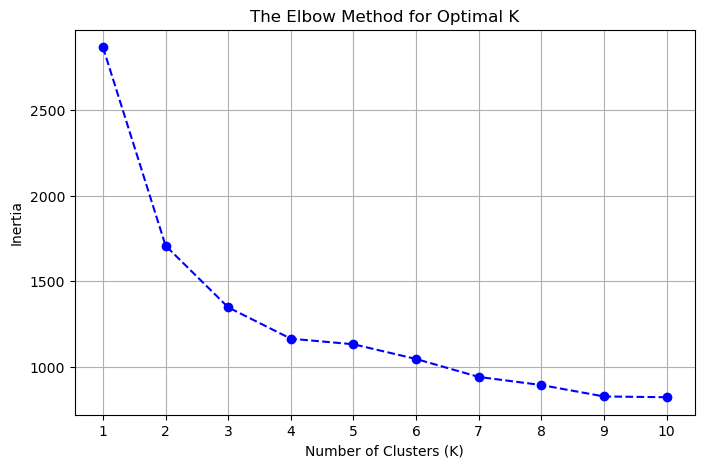

In [3]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(df)

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_norm)
    wcss.append(kmeans.inertia_)  # inertia_ calculates the WCSS score

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [24]:
#Teste com k=3
 
final_model = KMeans(n_clusters = 3, init='k-means++', random_state=42)
cluster_labels = final_model.fit_predict(X_norm)

In [25]:
centroids = final_model.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_orig, columns=df.columns)
centroids_df.index.name = "Cluster"

centroids_df

,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Cluster,,,,,,,,,,,,,,,,,,,
0,52.441183,77.629593,54.242424,79.232955,81.865152,75.652273,68.418939,60.031818,52.445769,65.159308,42.300235,62.144589,67.146433,60.668578,64.751218,55.925674,78.061209,64.858575,55.597643
1,36.433838,63.948758,38.977273,67.727273,59.093182,39.553409,36.913636,25.534091,33.009501,36.957664,26.408796,42.168544,64.458738,45.038550,54.935064,39.990847,69.469345,50.013961,58.385943
2,80.809321,88.915069,72.804878,94.375000,97.348780,92.506098,87.369512,86.878049,72.967146,85.391715,72.196509,78.192936,86.737502,83.150854,77.788367,81.502648,93.851886,89.584730,78.709350


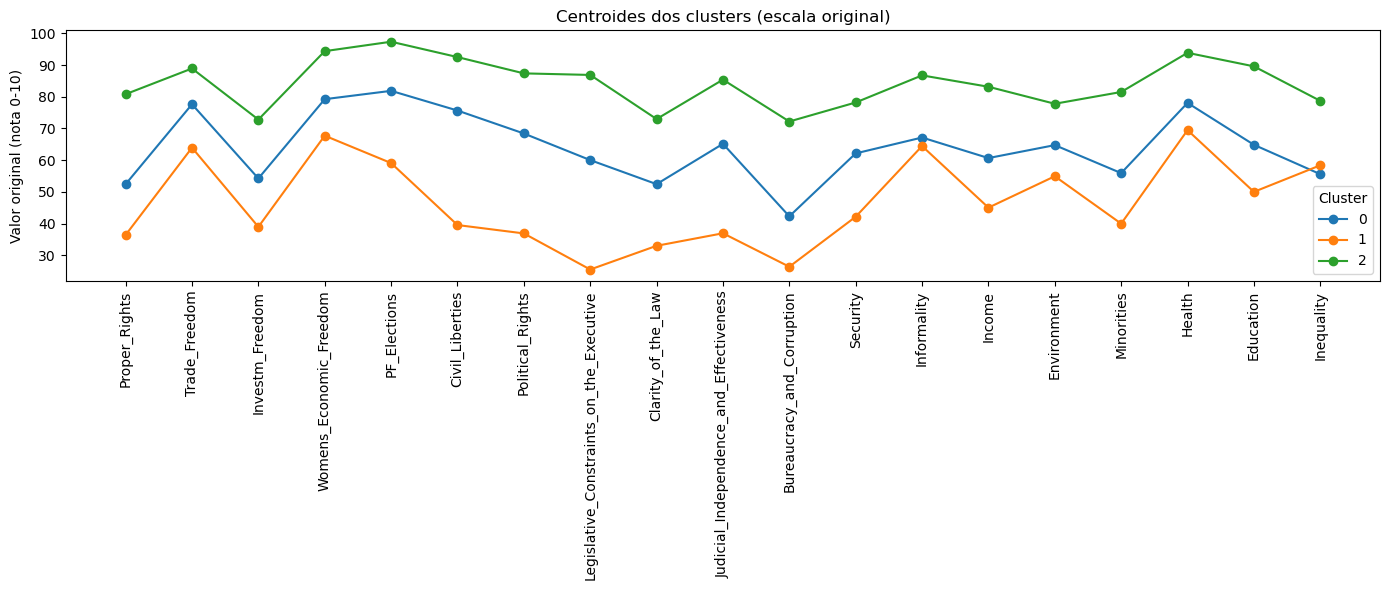

In [26]:
# Gráfico de linhas dos centroides na escala original
ax = centroids_df.T.plot(figsize=(14, 6), marker="o")
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=90)
ax.set_ylabel("Valor original (nota 0-10)")
ax.set_title("Centroides dos clusters (escala original)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()